In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:/Users/Dell/Desktop/hasnain/Internship/dataset/Titanic.csv")

In [4]:
print(df.head())


      sex   age  sibsp  parch     fare embarked  class    who  alone  survived
0    male  22.0      1      0   7.2500        S  Third    man  False         0
1  female  38.0      1      0  71.2833        C  First  woman  False         1
2  female  26.0      0      0   7.9250        S  Third  woman   True         1
3  female  35.0      1      0  53.1000        S  First  woman  False         1
4    male  35.0      0      0   8.0500        S  Third    man   True         0


In [5]:
print(df)

        sex   age  sibsp  parch     fare embarked   class    who  alone  \
0      male  22.0      1      0   7.2500        S   Third    man  False   
1    female  38.0      1      0  71.2833        C   First  woman  False   
2    female  26.0      0      0   7.9250        S   Third  woman   True   
3    female  35.0      1      0  53.1000        S   First  woman  False   
4      male  35.0      0      0   8.0500        S   Third    man   True   
..      ...   ...    ...    ...      ...      ...     ...    ...    ...   
886    male  27.0      0      0  13.0000        S  Second    man   True   
887  female  19.0      0      0  30.0000        S   First  woman   True   
888  female   NaN      1      2  23.4500        S   Third  woman  False   
889    male  26.0      0      0  30.0000        C   First    man   True   
890    male  32.0      0      0   7.7500        Q   Third    man   True   

     survived  
0           0  
1           1  
2           1  
3           1  
4           0  
.. 

In [6]:
print(df.isnull().sum())


sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
who           0
alone         0
survived      0
dtype: int64


In [7]:
df_cleaned = df.dropna()
print(df_cleaned.shape)  # Check new shape after removal


(712, 10)


In [8]:
print (df)

        sex   age  sibsp  parch     fare embarked   class    who  alone  \
0      male  22.0      1      0   7.2500        S   Third    man  False   
1    female  38.0      1      0  71.2833        C   First  woman  False   
2    female  26.0      0      0   7.9250        S   Third  woman   True   
3    female  35.0      1      0  53.1000        S   First  woman  False   
4      male  35.0      0      0   8.0500        S   Third    man   True   
..      ...   ...    ...    ...      ...      ...     ...    ...    ...   
886    male  27.0      0      0  13.0000        S  Second    man   True   
887  female  19.0      0      0  30.0000        S   First  woman   True   
888  female   NaN      1      2  23.4500        S   Third  woman  False   
889    male  26.0      0      0  30.0000        C   First    man   True   
890    male  32.0      0      0   7.7500        Q   Third    man   True   

     survived  
0           0  
1           1  
2           1  
3           1  
4           0  
.. 

In [9]:
df.isnull()

,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False,False
888,False,True,False,False,False,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False,False


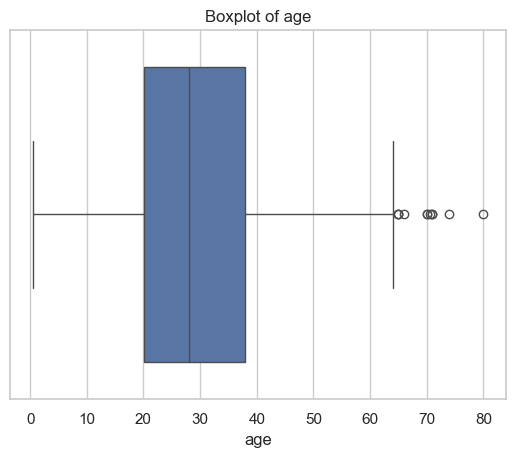

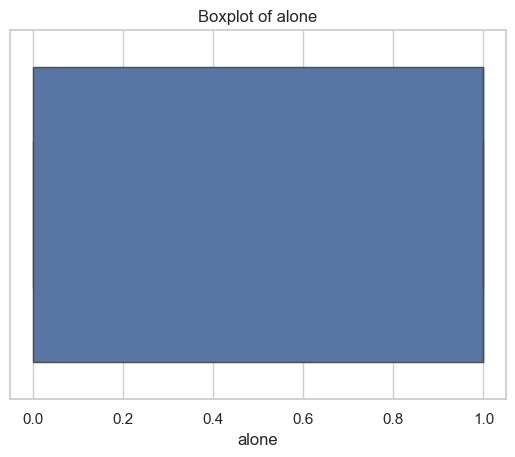

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for Fare
sns.boxplot(x=df['age'])
plt.title("Boxplot of age")
plt.show()

# Boxplot for Age
sns.boxplot(x=df['alone'])
plt.title("Boxplot of alone")
plt.show()

In [11]:
#Statistical Method: IQR (Interquartile Range)
#Outliers lie outside the range:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]
print("Number of age outliers:", outliers.shape[0])



Number of age outliers: 11


In [12]:
df_no_outliers = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]


In [13]:
df['age'] = df['age'].clip(lower=lower_bound, upper=upper_bound)


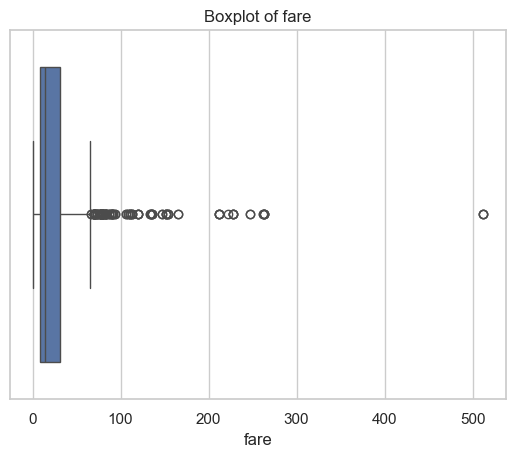

In [14]:
#we can take now fare column
# Boxplot for Age
sns.boxplot(x=df['fare'])
plt.title("Boxplot of fare")
plt.show()

In [15]:
#Statistical Method: IQR (Interquartile Range)
#Outliers lie outside the range:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
outliers = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]
print("Number of fare outliers:", outliers.shape[0])



Number of fare outliers: 116


In [16]:
df_no_outliers = df[(df['fare'] >= lower_bound) & (df['fare'] <= upper_bound)]


In [17]:
df['age'] = df['age'].clip(lower=lower_bound, upper=upper_bound)


In [18]:
#"Outliers were identified using both boxplots and the Interquartile Range (IQR) method. In the "age" column, extreme values above 11 were found and either removed or capped to reduce skewness. Similar analysis was done for the fare column to ensure data consistency and avoid biased model performance."

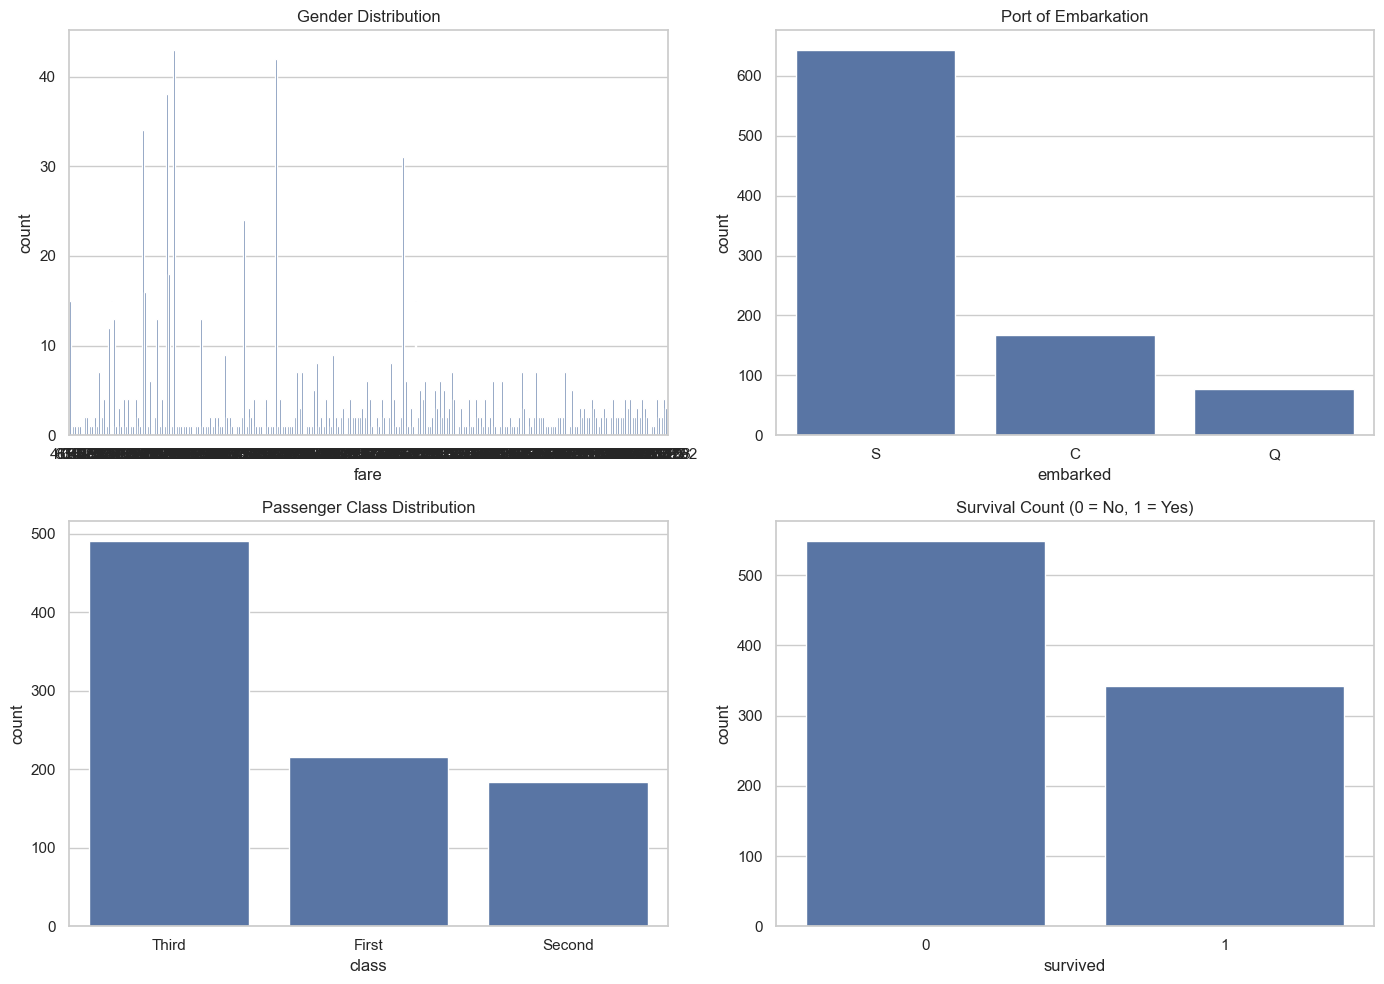

In [19]:
#Visualizations:
#Create bar charts for categorical variables.
import seaborn as sns
import matplotlib.pyplot as plt

# Set a general style
sns.set(style="whitegrid")

# Set figure size and layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gender distribution
sns.countplot(x="fare", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Gender Distribution")

# 2. Port of Embarkation
sns.countplot(x="embarked", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Port of Embarkation")

# 3. Passenger Class
sns.countplot(x="class", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Passenger Class Distribution")

# 4. Survival Status
sns.countplot(x="survived", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Survival Count (0 = No, 1 = Yes)")

# Adjust layout
plt.tight_layout()
plt.show()



In [8]:
import pandas as pd

# Replace with your actual path if needed
df = pd.read_csv("C:/Users/Dell/Desktop/hasnain/Internship/dataset/Titanic.csv")

# Quick check
df.head()


,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived
0,male,22.0,1,0,7.2500,S,Third,man,False,0
1,female,38.0,1,0,71.2833,C,First,woman,False,1
2,female,26.0,0,0,7.9250,S,Third,woman,True,1
3,female,35.0,1,0,53.1000,S,First,woman,False,1
4,male,35.0,0,0,8.0500,S,Third,man,True,0


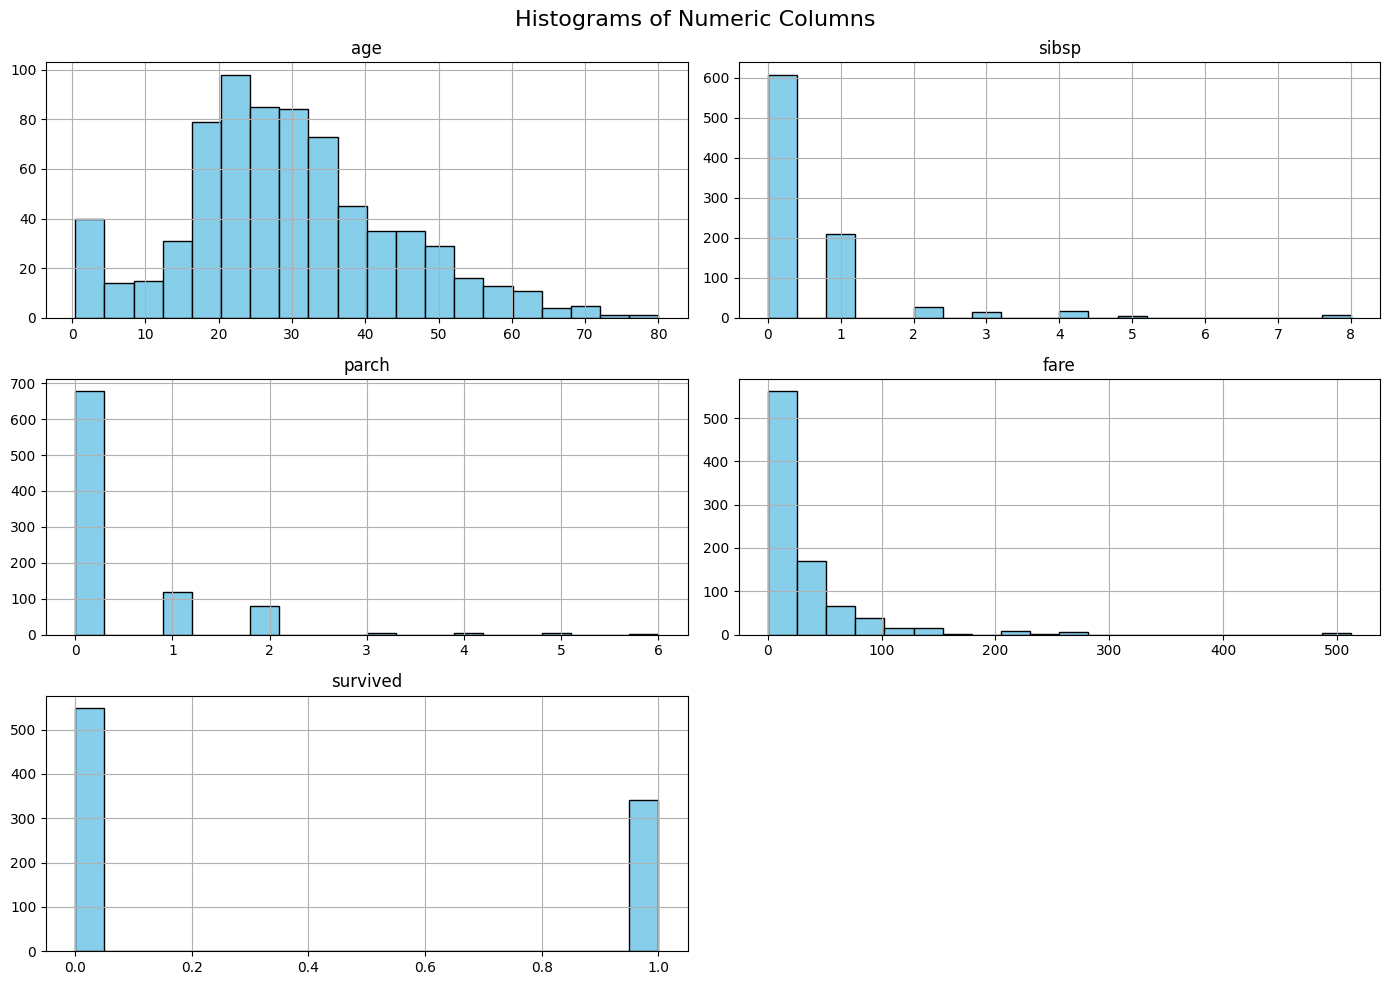

In [9]:
import matplotlib.pyplot as plt

# Select numeric columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms
df[numeric_columns].hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Columns", fontsize=16)
plt.tight_layout()
plt.show()


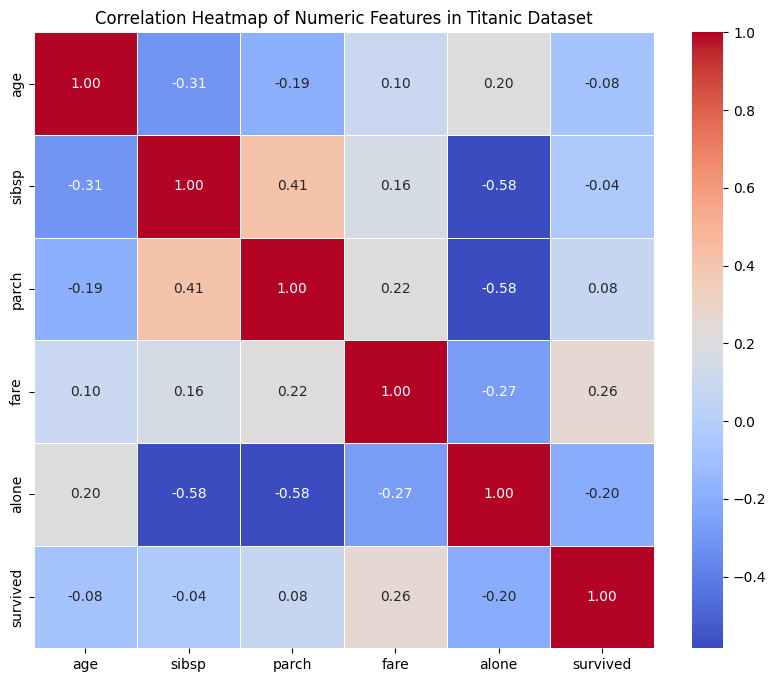

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix for numeric columns only
correlation_matrix = df.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Title
plt.title("Correlation Heatmap of Numeric Features in Titanic Dataset")
plt.show()


In [11]:
#🔍 Summary of Insights – Titanic Dataset
#1 Missing Values
#2 Duplicates
#3 Outliers
#4 Bar Charts (Categorical Variables)
#5 Histograms (Numerical Variables)
#6 Correlation Heatmap
#✅ Final Thoughts
#This EDA shows that class, gender, and fare played important roles in survival outcomes. Further analysis using machine learning models could explore these relationships in greater depth.

